In [1]:
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

prices = pd.read_csv("../data/prices.csv")
fin_df = pd.read_csv("../data/financials.csv")

print("Datos cargados OK")
print(prices.head(3))

Datos cargados OK
         date      close company ticker
0  2019-01-02  87.238594     SAP    SAP
1  2019-01-03  83.966492     SAP    SAP
2  2019-01-04  86.851578     SAP    SAP


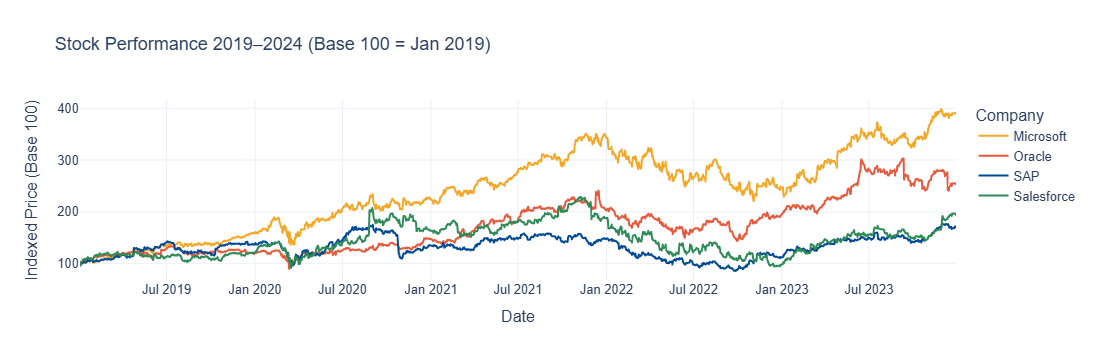

In [2]:
# Normalizar precios a base 100 para comparar rendimiento relativo
prices["date"] = pd.to_datetime(prices["date"])
prices = prices.sort_values(["company", "date"])

base_prices = prices.groupby("company").first()["close"]

prices["close_norm"] = prices.apply(
    lambda row: row["close"] / base_prices[row["company"]] * 100,
    axis=1
)

fig = px.line(
    prices,
    x="date",
    y="close_norm",
    color="company",
    title="Stock Performance 2019–2024 (Base 100 = Jan 2019)",
    labels={"date": "Date", "close_norm": "Indexed Price (Base 100)", "company": "Company"},
    color_discrete_map={
        "SAP":        "#004A96",
        "Oracle":     "#E8593C",
        "Salesforce": "#2E8B57",
        "Microsoft":  "#F5A623"
    }
)

fig.update_layout(
    template="plotly_white",
    font=dict(family="Arial", size=13),
    hovermode="x unified",
    legend_title="Company"
)

fig.show()

In [3]:
# Datos de reportes anuales SAP (en miles de millones EUR)
sap_revenue = pd.DataFrame({
    "year": [2019, 2020, 2021, 2022, 2023],
    "total_revenue":  [27.55, 27.34, 27.84, 30.87, 31.21],
    "cloud_revenue":  [6.93,  8.08,  9.45,  11.57, 13.66],
    "license_revenue":[5.11,  4.45,  3.25,  2.07,  1.51],
    "services_revenue":[4.29, 3.97,  3.79,  3.85,  3.87]
})

sap_revenue["cloud_pct"] = (sap_revenue["cloud_revenue"] / sap_revenue["total_revenue"] * 100).round(1)

print("SAP Revenue Breakdown (EUR bn):")
print(sap_revenue.to_string(index=False))

SAP Revenue Breakdown (EUR bn):
 year  total_revenue  cloud_revenue  license_revenue  services_revenue  cloud_pct
 2019          27.55           6.93             5.11              4.29       25.2
 2020          27.34           8.08             4.45              3.97       29.6
 2021          27.84           9.45             3.25              3.79       33.9
 2022          30.87          11.57             2.07              3.85       37.5
 2023          31.21          13.66             1.51              3.87       43.8


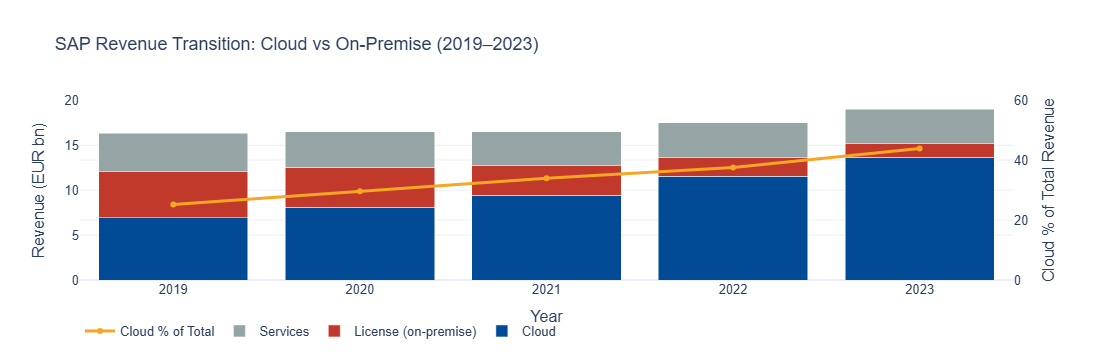

In [4]:
fig2 = go.Figure()

fig2.add_trace(go.Bar(
    x=sap_revenue["year"],
    y=sap_revenue["cloud_revenue"],
    name="Cloud",
    marker_color="#004A96"
))

fig2.add_trace(go.Bar(
    x=sap_revenue["year"],
    y=sap_revenue["license_revenue"],
    name="License (on-premise)",
    marker_color="#C0392B"
))

fig2.add_trace(go.Bar(
    x=sap_revenue["year"],
    y=sap_revenue["services_revenue"],
    name="Services",
    marker_color="#95A5A6"
))

fig2.add_trace(go.Scatter(
    x=sap_revenue["year"],
    y=sap_revenue["cloud_pct"],
    name="Cloud % of Total",
    yaxis="y2",
    line=dict(color="#F5A623", width=3),
    mode="lines+markers"
))

fig2.update_layout(
    title="SAP Revenue Transition: Cloud vs On-Premise (2019–2023)",
    barmode="stack",
    xaxis_title="Year",
    yaxis_title="Revenue (EUR bn)",
    yaxis2=dict(
        title="Cloud % of Total Revenue",
        overlaying="y",
        side="right",
        range=[0, 60]
    ),
    template="plotly_white",
    font=dict(family="Arial", size=13),
    legend=dict(orientation="h", y=-0.2)
)

fig2.show()

In [5]:
sap_revenue.to_csv("../data/sap_revenue.csv", index=False)
prices_norm = prices[["date", "company", "close", "close_norm"]]
prices_norm.to_csv("../data/prices_normalized.csv", index=False)

print("Guardado OK")
print(f"\nCloud % evolution:")
for _, row in sap_revenue.iterrows():
    print(f"  {int(row['year'])}: {row['cloud_pct']}%")

Guardado OK

Cloud % evolution:
  2019: 25.2%
  2020: 29.6%
  2021: 33.9%
  2022: 37.5%
  2023: 43.8%
